In [49]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
in_df = pd.read_csv("epl_final.csv")

In [14]:
in_df #initial df

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,...,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,...,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,...,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,...,7,2,3,6,10,11,2,2,0,0


In [18]:
in_df.columns

Index(['Season', 'MatchDate', 'HomeTeam', 'AwayTeam', 'FullTimeHomeGoals',
       'FullTimeAwayGoals', 'FullTimeResult', 'HalfTimeHomeGoals',
       'HalfTimeAwayGoals', 'HalfTimeResult', 'HomeShots', 'AwayShots',
       'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners',
       'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards',
       'HomeRedCards', 'AwayRedCards'],
      dtype='object')

In [24]:
in_df.isna().sum() #checking for null values

Season               0
MatchDate            0
HomeTeam             0
AwayTeam             0
FullTimeHomeGoals    0
FullTimeAwayGoals    0
FullTimeResult       0
HalfTimeHomeGoals    0
HalfTimeAwayGoals    0
HalfTimeResult       0
HomeShots            0
AwayShots            0
HomeShotsOnTarget    0
AwayShotsOnTarget    0
HomeCorners          0
AwayCorners          0
HomeFouls            0
AwayFouls            0
HomeYellowCards      0
AwayYellowCards      0
HomeRedCards         0
AwayRedCards         0
dtype: int64

In [28]:
in_df.duplicated().sum() #checking for duplicated rows

np.int64(0)

<Axes: xlabel='count', ylabel='FullTimeResult'>

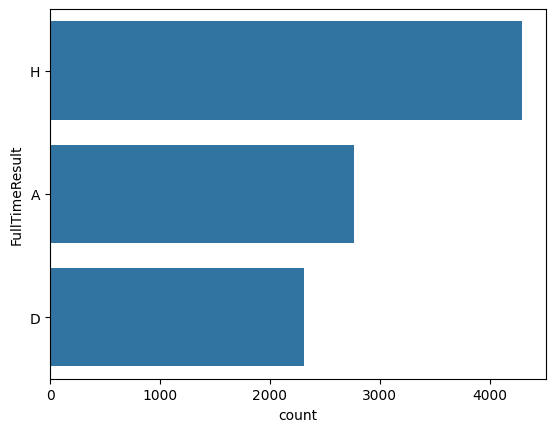

In [36]:
sns.countplot(in_df["FullTimeResult"])

In [52]:
Home_wins=sum(in_df["FullTimeResult"]=="H")
Away_wins=sum(in_df["FullTimeResult"]=="A")
Draws=sum(in_df["FullTimeResult"]=="D")
count=in_df["FullTimeResult"].count()
PercentDrawn = float(Draws/count*100)
PercentWon_Home = float(Home_wins/count*100)
PercentWon_Away = float(Away_wins/count*100)

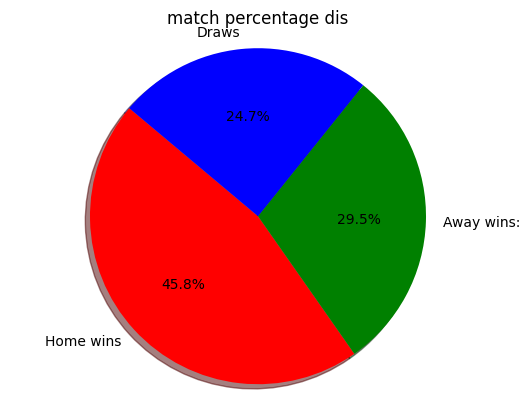

In [60]:
plt.pie([Home_wins,Away_wins,Draws],labels=["Home wins","Away wins:","Draws"], colors=["red","green","blue"],
autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('match percentage dis')
plt.axis('equal')
plt.show()

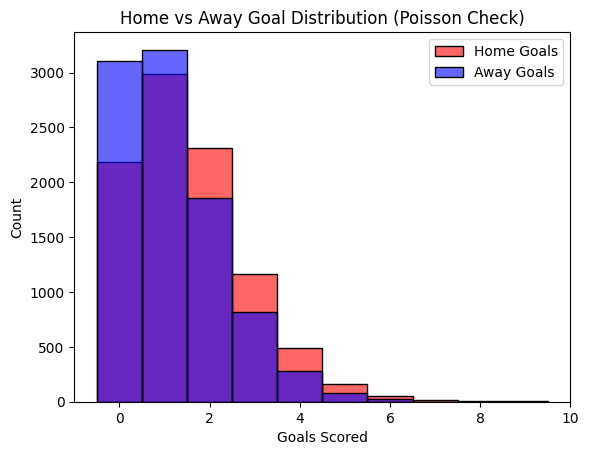

In [64]:
sns.histplot(data=in_df, x="FullTimeHomeGoals", color="red", label="Home Goals", discrete=True, alpha=0.6)
sns.histplot(data=in_df, x="FullTimeAwayGoals", color="blue", label="Away Goals", discrete=True, alpha=0.6)

plt.legend()
plt.title("Home vs Away Goal Distribution (Poisson Check)")
plt.xlabel("Goals Scored")
plt.show()

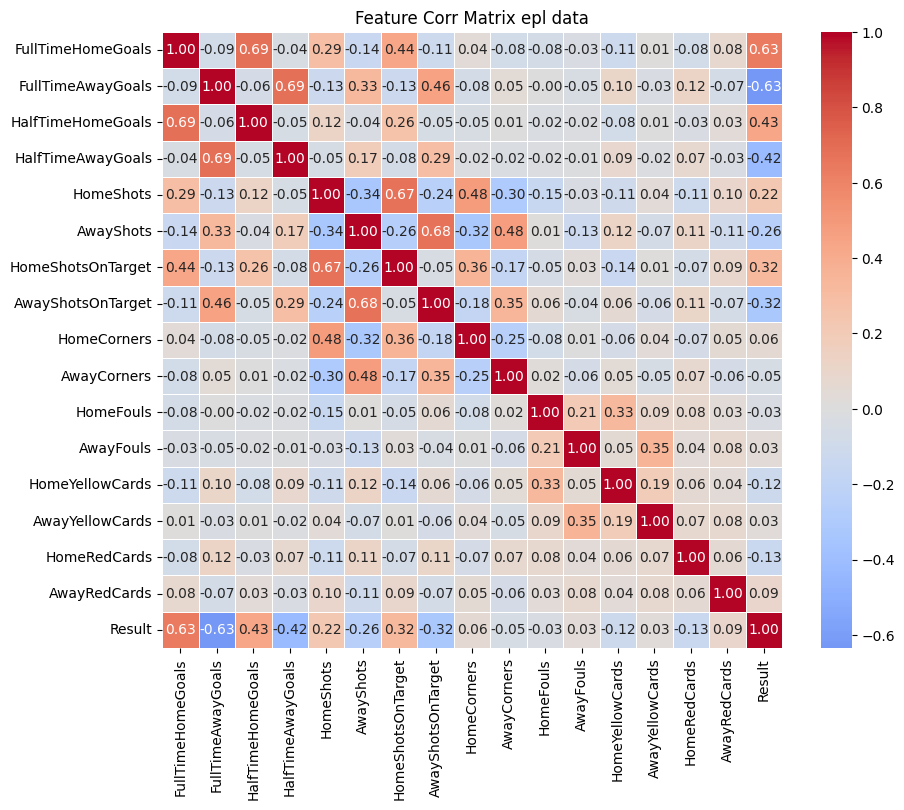

In [73]:
hdf=in_df.copy()
hdf["Result"]=hdf["FullTimeResult"].map({"H":1,"D":0,"A":-1})
ncols=hdf.select_dtypes(include=[np.number])
corr_mtx=ncols.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_mtx,annot=True,fmt=".2f",
           cmap="coolwarm",center=0,linewidths=0.5)
plt.title("Feature Corr Matrix epl data")
plt.show()

In [74]:

cols_to_drop = [
    'HomeFouls', 'AwayFouls', 
    'HomeYellowCards', 'AwayYellowCards', 
    'HomeCorners', 'AwayCorners', 
    'HomeShots', 'AwayShots'  # We are keeping 'ShotsOnTarget' instead
]

in_df.drop(columns=cols_to_drop, inplace=True)

print(in_df.columns)

Index(['Season', 'MatchDate', 'HomeTeam', 'AwayTeam', 'FullTimeHomeGoals',
       'FullTimeAwayGoals', 'FullTimeResult', 'HalfTimeHomeGoals',
       'HalfTimeAwayGoals', 'HalfTimeResult', 'HomeShotsOnTarget',
       'AwayShotsOnTarget', 'HomeRedCards', 'AwayRedCards'],
      dtype='object')


In [75]:
in_df.drop(columns=['Season'], inplace=True, errors='ignore')

In [76]:
in_df['MatchDate'] = pd.to_datetime(in_df['MatchDate'])
in_df = in_df.sort_values(by='MatchDate')

In [77]:
in_df

,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShotsOnTarget,AwayShotsOnTarget,HomeRedCards,AwayRedCards
0,2000-08-19,Charlton,Man City,4,0,H,2,0,H,14,4,0,0
1,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,10,5,0,0
2,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,3,9,1,0
3,2000-08-19,Derby,Southampton,2,2,D,1,2,A,4,6,0,0
4,2000-08-19,Leeds,Everton,2,0,H,2,0,H,8,6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9377,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,2,2,0,0
9378,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,7,2,0,0
9375,2025-05-04,Brentford,Man United,4,3,H,2,1,H,6,5,0,0
9376,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,2,5,0,0


In [ ]:
import pandas as pd

in_df['MatchDate'] = pd.to_datetime(in_df['MatchDate'])
in_df = in_df.sort_values(by='MatchDate')

home_games = in_df[['MatchDate', 'HomeTeam', 'FullTimeHomeGoals', 'FullTimeAwayGoals']].copy()
home_games.columns = ['Date', 'Team', 'GoalsFor', 'GoalsAgainst']

away_games = in_df[['MatchDate', 'AwayTeam', 'FullTimeAwayGoals', 'FullTimeHomeGoals']].copy()
away_games.columns = ['Date', 'Team', 'GoalsFor', 'GoalsAgainst']

all_games = pd.concat([home_games, away_games]).sort_values(['Team', 'Date'])

grouped = all_games.groupby('Team')

all_games['Form_GoalsScored'] = grouped['GoalsFor'].transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
all_games['Form_GoalsConceded'] = grouped['GoalsAgainst'].transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())

in_df = pd.merge(in_df, all_games[['Date', 'Team', 'Form_GoalsScored', 'Form_GoalsConceded']],
                 left_on=['MatchDate', 'HomeTeam'], right_on=['Date', 'Team'], how='left')
in_df.rename(columns={'Form_GoalsScored': 'Home_GoalsScored_Last5', 
                      'Form_GoalsConceded': 'Home_GoalsConceded_Last5'}, inplace=True)
in_df.drop(columns=['Date', 'Team'], inplace=True)

in_df = pd.merge(in_df, all_games[['Date', 'Team', 'Form_GoalsScored', 'Form_GoalsConceded']],
                 left_on=['MatchDate', 'AwayTeam'], right_on=['Date', 'Team'], how='left')
in_df.rename(columns={'Form_GoalsScored': 'Away_GoalsScored_Last5', 
                      'Form_GoalsConceded': 'Away_GoalsConceded_Last5'}, inplace=True)
in_df.drop(columns=['Date', 'Team'], inplace=True)